# SECTION 1 — INTRODUCTIOPN NETFLIX MOVIES

## Objective
This project focuses on cleaning and analyzing the Netflix Movies and TV Shows dataset. The goal is to transform raw data into a clean, structured dataset and extract meaningful insights through exploratory data analysis.

The emphasis of this task is **data cleaning**, including handling missing values, duplicates, standardization, and data validation.

After cleaning, exploratory analysis is performed to understand content distribution, trends, and patterns in Netflix’s catalog.

## SECTION 2 — LOAD DATA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# LOAD DATASET
df= pd.read_csv("netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
# SECTION 3 — DATASET UNDERSTANDING (MANDATORY)

In [4]:
df.shape

(8807, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [6]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [7]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


##  Dataset Overview

- Rows: 8807
- Columns: 12

### Numerical Features:
- release_year

### Categorical Features:
- type, title, director, cast, country, rating, duration, listed_in, description

### Potential Primary Key:
- show_id (unique identifier for each record)

### Dataset Description:
This dataset contains information about Netflix movies and TV shows including title, director, cast, country, release year, rating, and category.

## SECTION 4 — DATA CLEANING (TASK 2)

In [8]:
# CHECK MISSING VALUES
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [9]:
# HANDLE MISSING VALUES
#  Reasoning: Netflix dataset is mostly categorical so i use fill instead of drop 

df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Unknown')

In [10]:
# DROP ROWS ONLY IF CRITICAL FIELDS MISSING
df.dropna(subset=['title', 'date_added'], inplace=True)

In [11]:
# CHECK DUPLICATES
df.duplicated().sum()

np.int64(0)

In [12]:
# REMOVE DUPLICATES
df.drop_duplicates(inplace=True)

In [13]:
# STANDARDIZATION
# COLUMN NAME STANDARDIZATION
df.columns = df.columns.str.lower().str.replace(" ", "_")
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [14]:
# TEXT STANDARDIZATION 
df['country'] = df['country'].str.lower().str.strip()
df['type'] = df['type'].str.lower().str.strip()
df['rating'] = df['rating'].str.upper()

In [15]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

In [16]:
# EXTRACT YEAR & MONTH (GOOD FOR LATER EDA)
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

In [17]:
# DATA VALIDATION
df['release_year'].describe()

count    8797.000000
mean     2014.183472
std         8.822191
min      1925.000000
25%      2013.000000
50%      2017.000000
75%      2019.000000
max      2021.000000
Name: release_year, dtype: float64

In [18]:
# REMOVE FUTURE OR INVALID YEARS
df = df[df['release_year'] <= 2026]

In [19]:
# CHECK EMPTY STRINGS
df.replace(" ", np.nan, inplace=True)

In [20]:
# SUMMARY TABLE 
summary = pd.DataFrame({
    "Issue Found": [
        "Missing Values",
        "Duplicates",
        "Inconsistent Text Format",
        "Date Format Issues",
        "Invalid Release Years"
    ],
    "Action Taken": [
        "Filled categorical columns with 'Unknown', dropped critical nulls",
        "Removed duplicate records",
        "Standardized text to lower/upper case",
        "Converted date_added to datetime format",
        "Filtered invalid release years"
    ]
})

summary

,Issue Found,Action Taken
0,Missing Values,"Filled categorical columns with 'Unknown', dro..."
1,Duplicates,Removed duplicate records
2,Inconsistent Text Format,Standardized text to lower/upper case
3,Date Format Issues,Converted date_added to datetime format
4,Invalid Release Years,Filtered invalid release years


## Netflix Data Cleaning Summary

The dataset was cleaned using the following steps:

- Missing values in director, cast, country, and rating were filled with 'Unknown'
- Critical missing values in title and date_added were removed
- Duplicate records were identified and removed
- Column names were standardized to lowercase format
- Text fields such as country and type were cleaned for consistency
- Date_added was converted into datetime format for time-based analysis
- Additional features such as year_added and month_added were extracted
- Invalid release years were filtered to ensure data accuracy

This ensures the dataset is now clean, structured, and ready for exploratory analysis.

 # SECTION 5 — EDA + VISUALIZATION 

In [21]:
# 1. MOVIES VS TV SHOWS
df['type'].value_counts()

type
movie      6131
tv show    2666
Name: count, dtype: int64

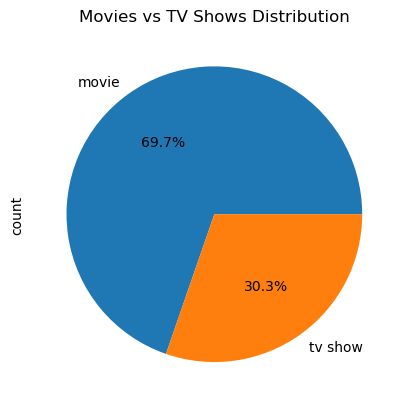

In [22]:
df['type'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Movies vs TV Shows Distribution")
plt.show()

In [23]:
# 2. TOP COUNTRIES
df['country'].value_counts().head(10)

country
united states     2812
india              972
unknown            830
united kingdom     418
japan              244
south korea        199
canada             181
spain              145
france             124
mexico             110
Name: count, dtype: int64

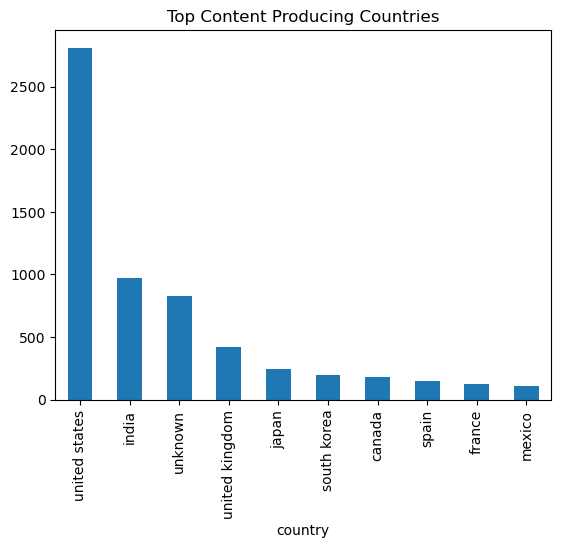

In [24]:
df['country'].value_counts().head(10).plot(kind='bar')
plt.title("Top Content Producing Countries")
plt.show()

In [25]:
# 3. CONTENT ADDED OVER TIME
df['year_added'].value_counts().sort_index()

year_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      10
2014.0      23
2015.0      73
2016.0     418
2017.0    1164
2018.0    1625
2019.0    1999
2020.0    1878
2021.0    1498
Name: count, dtype: int64

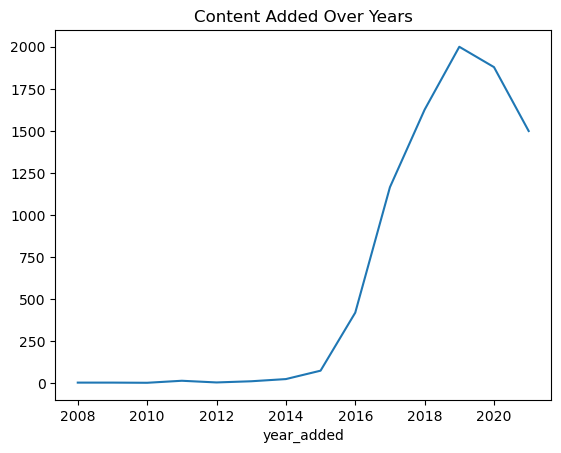

In [26]:
df['year_added'].value_counts().sort_index().plot(kind='line')
plt.title("Content Added Over Years")
plt.show()

In [27]:
# 4. MOST COMMON RATINGS
df['rating'].value_counts().head(10)

rating
TV-MA    3205
TV-14    2157
TV-PG     861
R         799
PG-13     490
TV-Y7     333
TV-Y      306
PG        287
TV-G      220
NR         79
Name: count, dtype: int64

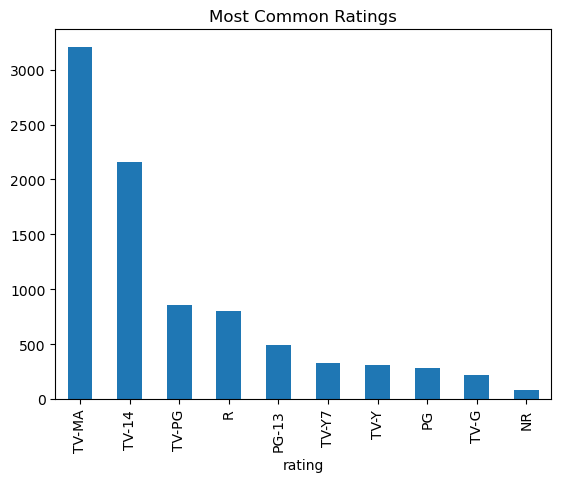

In [28]:
df['rating'].value_counts().head(10).plot(kind='bar')
plt.title("Most Common Ratings")
plt.show()

In [21]:
# 5. MOST COMMON GENRES
df['listed_in'].value_counts().head(5)

listed_in
Dramas, International Movies                        362
Documentaries                                       359
Stand-Up Comedy                                     334
Comedies, Dramas, International Movies              274
Dramas, Independent Movies, International Movies    252
Name: count, dtype: int64

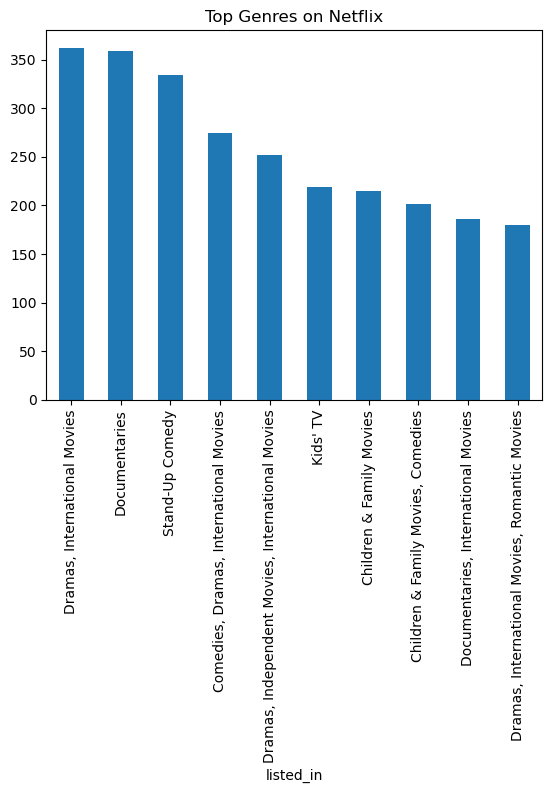

In [30]:
df['listed_in'].value_counts().head(10).plot(kind='bar')
plt.title("Top Genres on Netflix")
plt.show()

## SECTION 6 — FINAL INSIGHTS

1. Netflix has more movies than TV shows, indicating a stronger focus on film content.
2. The United States is the leading producer of Netflix content globally.
3. Most content was added between 2016–2020, showing rapid platform expansion.
4. TV-MA and TV-14 are the most common content ratings, targeting mature audiences.
5. Drama and International Movies dominate Netflix’s genre distribution.

In [31]:
df.to_csv("cleaned_data.csv", index=False)